AQI DASHBOARD SUMMARY (2020–2024)
Average AQI: 252.78
Maximum AQI: 499.90
Minimum AQI: 0.40
Total Observation Days: 1827


C:\Users\hi\AppData\Local\Temp\ipykernel_4200\2217397658.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


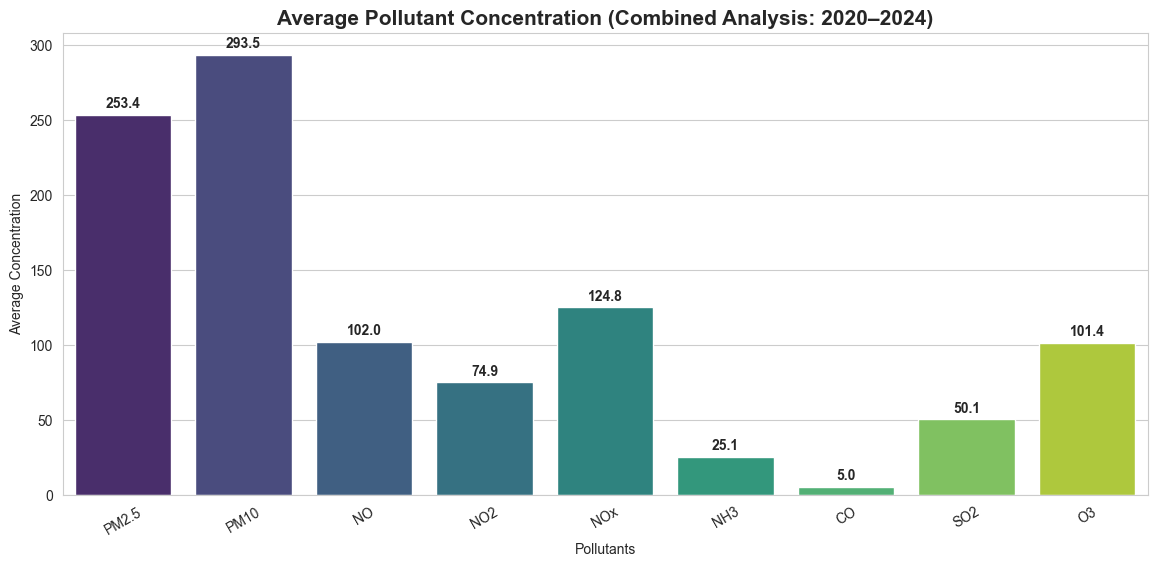

C:\Users\hi\AppData\Local\Temp\ipykernel_4200\2217397658.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


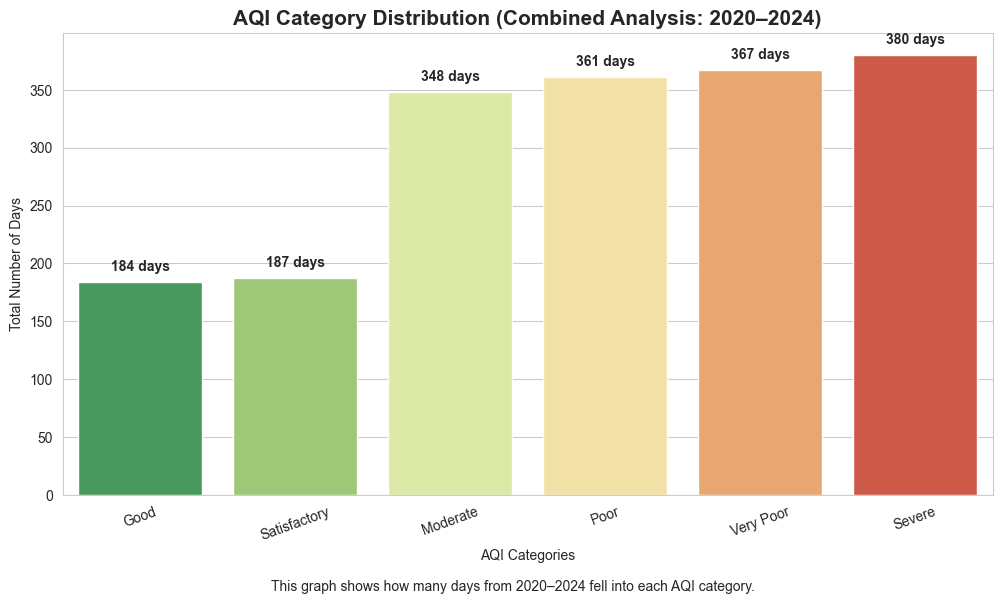


KEY INSIGHTS
Most dominant pollutant: PM10
Most frequent AQI category: Severe
Total Severe AQI Days: 380
Total Good AQI Days: 184

Observation:
Delhi experienced a large number of Poor, Very Poor and Severe AQI days
during the 2020–2024 study period, indicating persistent pollution issues.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# SETTINGS
# =========================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("../data/cleaned_aqi_final.csv")
df['Date'] = pd.to_datetime(df['Date'])

# =========================
# AQI CATEGORY FUNCTION
# =========================
def get_aqi_category(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Satisfactory'
    elif aqi <= 200:
        return 'Moderate'
    elif aqi <= 300:
        return 'Poor'
    elif aqi <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

df['AQI_Category'] = df['AQI'].apply(get_aqi_category)

# =========================
# POLLUTANTS
# =========================
pollutants = [
    'PM2.5',
    'PM10',
    'NO',
    'NO2',
    'NOx',
    'NH3',
    'CO',
    'SO2',
    'O3'
]

# =========================
# KPI SUMMARY
# =========================
print("="*60)
print("AQI DASHBOARD SUMMARY (2020–2024)")
print("="*60)

print(f"Average AQI: {df['AQI'].mean():.2f}")
print(f"Maximum AQI: {df['AQI'].max():.2f}")
print(f"Minimum AQI: {df['AQI'].min():.2f}")
print(f"Total Observation Days: {len(df)}")

# =========================
# GRAPH 1
# AVERAGE POLLUTANT CONCENTRATION
# =========================
pollutant_means = df[pollutants].mean()

plt.figure(figsize=(14,6))

sns.barplot(
    x=pollutants,
    y=pollutant_means.values,
    palette='viridis'
)

plt.title(
    "Average Pollutant Concentration (Combined Analysis: 2020–2024)",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Pollutants")
plt.ylabel("Average Concentration")
plt.xticks(rotation=30)

for i, value in enumerate(pollutant_means.values):
    plt.text(
        i,
        value + 5,
        f"{value:.1f}",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.show()

# =========================
# GRAPH 2
# AQI CATEGORY DISTRIBUTION
# =========================
aqi_counts = df['AQI_Category'].value_counts().reindex(
    ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=aqi_counts.index,
    y=aqi_counts.values,
    palette='RdYlGn_r'
)

for i, value in enumerate(aqi_counts.values):
    plt.text(
        i,
        value + 10,
        f"{value} days",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    "AQI Category Distribution (Combined Analysis: 2020–2024)",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("AQI Categories")
plt.ylabel("Total Number of Days")
plt.xticks(rotation=20)

plt.figtext(
    0.5,
    -0.05,
    "This graph shows how many days from 2020–2024 fell into each AQI category.",
    ha='center',
    fontsize=10
)

plt.show()

# =========================
# KEY INSIGHTS
# =========================
print("\n" + "="*60)
print("KEY INSIGHTS")
print("="*60)

top_pollutant = pollutant_means.idxmax()
worst_category = aqi_counts.idxmax()

print(f"Most dominant pollutant: {top_pollutant}")
print(f"Most frequent AQI category: {worst_category}")
print(f"Total Severe AQI Days: {aqi_counts['Severe']}")
print(f"Total Good AQI Days: {aqi_counts['Good']}")

print("\nObservation:")
print("Delhi experienced a large number of Poor, Very Poor and Severe AQI days")
print("during the 2020–2024 study period, indicating persistent pollution issues.")